<a href="https://colab.research.google.com/github/LampOfSocrates/reid/blob/main/EEEM071_CourseWork2604_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This insures that 2 seconda after editing a module it gets reloaded without restarting the kernel
%load_ext autoreload
%autoreload 2

# Step 1: GPU Selection
1. Find "Edit" tab above, select "Hardware accelerator" and choose "GPU"
2. Run bellow command to check what GPU you got

In [2]:
from datetime import datetime

NOTEBOOK_START_TIME = datetime.now()
print(NOTEBOOK_START_TIME)

2026-04-27 16:44:15.840581


In [3]:
!nvidia-smi

Mon Apr 27 16:44:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.97                 Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   42C    P8             24W /  300W |    5864MiB /  16303MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Step 2: Colab and Local Path Preparation

We need to maintain our codebase with git history, so a file system (Google Drive) is needed
1. Select the left file icon and mount your Google Drive
2. Move path to Google Drive
3. Git clone code base


In [4]:
%%time
from pprint import pprint
from pathlib import Path
import sys
import os

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if is_colab():
  from google.colab import drive
  drive.mount('/content/drive')

  %cd /content
  #!pip install -U --no-cache-dir gdown --pre

  # please download datasets from assignment doc link and upload, then unzip it.

  # Copy the uploaded zip from Google Drive into the Colab runtime, then unzip it locally.
  if not os.path.exists('/content/VeRi'):
      print('Unzipping VeRi dataset...')
      !cp "/content/drive/MyDrive/Colab Notebooks/data/VeRi.zip" /content/VeRi.zip
      !unzip /content/VeRi.zip -d /content/
  else:
      print('VeRi dataset already exists. Skipping unzip.')
  %ls -l /content

  # code
  if not os.path.exists('/content/reid'):
      print('Cloning repository...')
      !git clone https://github.com/LampOfSocrates/reid /content/reid
  else:
      print('Repository already exists. Pulling latest changes...')
      %cd /content/reid
      !git pull
  %cd /content/reid
  %pip install -r requirements_colab.txt

  # Pre-resize VeRi to VeRi224 (skipped if already done)
  if not os.path.exists('/content/VeRi224/image_train'):
      print('Pre-resizing VeRi → VeRi224 ...')
      !python convert_224.py --src /content/VeRi --dst /content/VeRi224
  else:
      print('VeRi224 already exists. Skipping conversion.')

  repo_root = Path('/content/reid')
  data_root = Path('/content')

else: # Local run 
    repo_root = Path.cwd()
    data_root = Path(r'C:\Users\soura\Code\2026\reid\data')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'is_colab={is_colab()}')
print(f'repo_root={repo_root}')
print(f'data_root={data_root}')

is_colab=False
repo_root=C:\Users\soura\Code\2026\reid
data_root=C:\Users\soura\Code\2026\reid\data
CPU times: total: 0 ns
Wall time: 1.03 ms


In [6]:
if is_colab():
    from IPython.display import Javascript, display
    display(Javascript("""
        setInterval(() => {
            const btn = document.querySelector('#connect');
            if (btn) btn.click();
        }, 60000);
    """))
    print("Keep-alive started: clicking reconnect every 60 s")

 Note that we have a folder called /content/drive/MyDrive/Veri with the full data

# Set Globals

6 model runs take 30 minutes with DATA_FRACTION at 1% and MAX_EPOCH at 10 . vgg16 doesnt even respond to that.

Let this be the checked in combination


In [7]:
from coursework.src.utils.metrics_report import render_run, compare_runs, export_html
from datetime import datetime

if is_colab(): #8 / 20 run 
    MAX_EPOCH = 60
    DATA_FRACTION = 1
else: 
    MAX_EPOCH = 30  # only used if model specific max_epoch is not set 
    DATA_FRACTION = 1
RUNTIME = datetime.now().strftime("%d%m_%H%M")


# Section 1 Runs

In [8]:
# Defaults shared by all experiments. Anything in BASE_CFG can be overridden
# per-experiment via the dict below.
BASE_CFG = {
    "optim": "amsgrad",
    "lr": "0.0003",
    "train_batch_size": 64,
    "test_batch_size": 100,
    "workers": 2 if is_colab() else 8,
    "stepsize": "20 40",
    "eval_freq": 4,
    "patience": 10,
}

DRIVE_SYNC = "/content/drive/MyDrive/Colab Notebooks/reid/logs" if is_colab() else ""

# Each entry: experiment name -> {arch + any overrides that differ from BASE_CFG}
# Hyperparameters drawn from the original papers in coursework/papers/ (see knowledge.md sec 8)
SECTION_1_MODELS = {
    #"mobilenet_v3_small": {"arch": "mobilenet_v3_small"},
    #"resnet50_fc512":     {"arch": "resnet50_fc512"},
    "resnet18": {"arch": "resnet18"},
    "resnet18_fc512": {"arch": "resnet50_fc512"},
    # Swin-T -- Li et al., Array 16 (2022) 100255: lr/optim from BoT; K=4 from TransReID recipe.
    # "swin_t_custom": {"arch": "swin_t_custom", "lr": "3.5e-4", "lr_scheduler": "multi_step_warmup", "warmup_epochs": 10},
    # "swin_t_fc512":  {"arch": "swin_t_fc512",  "lr": "3.5e-4", "lr_scheduler": "multi_step_warmup", "warmup_epochs": 10},
    
    # CLIP-SENet v1 dual -- arXiv 2502.16815 sec IV.B.1: ADAM, lr 5e-4, cosine,
    # batch 128 = 16 IDs x 8 imgs/ID -> num_instances=8.
    #"clip_senet_v1_dual": {"arch": "clip_senet_v1_dual","lr": "5e-4","lr_scheduler": "cosine","num_instances": 8, "train_batch_size": 128,},
    # CLIP-SENet v3 -- same paper recipe (cosine, lr 5e-4, K=8).
    #"clip_senet_v3_ibn_supcon": {"arch": "clip_senet_v3_ibn_supcon", "lr": "5e-4","lr_scheduler": "cosine","num_instances": 8,"train_batch_size": 128,    },
    # "clip_senet_v2_frozen": {"arch": "clip_senet_v2_frozen", "lr": "1e-3", "lr_scheduler": "cosine", "num_instances": 8},  # disabled
}


def run_experiment(name, cfg, question="Q1", extra_args=()):
    cfg = {**BASE_CFG, **cfg}  # per-experiment overrides win
    arch = cfg["arch"]
    save_dir = f"logs/{RUNTIME}/{question}/{name}-veri"
    max_epoch = cfg.get("max_epoch", MAX_EPOCH)  # cfg override > global default
    scheduler_flags = ""
    if "lr_scheduler" in cfg:
        scheduler_flags += f"--lr-scheduler {cfg['lr_scheduler']} "
    if cfg.get("warmup_epochs"):
        scheduler_flags += f"--warmup-epochs {cfg['warmup_epochs']} "
    if cfg.get("num_instances"):
        scheduler_flags += f"--num-instances {cfg['num_instances']} "
    drive_sync_flag = f"--drive-sync-dir \"{DRIVE_SYNC}\" " if DRIVE_SYNC else ""
    cmd = (
        f"python coursework/main.py "
        f"-s veri -t veri -a {arch} "
        f"--experiment {name} "
        f"--root {data_root} "
        f"--height 224 --width 224 "
        f"--optim {cfg['optim']} --lr {cfg['lr']} "
        f"--max-epoch {max_epoch} "
        f"--stepsize {cfg['stepsize']} "
        f"--eval-freq {cfg['eval_freq']} "
        f"--patience {cfg['patience']} "
        f"--train-batch-size {cfg['train_batch_size']} "
        f"--test-batch-size {cfg['test_batch_size']} "
        f"--workers {cfg['workers']} "
        f"--data-fraction {DATA_FRACTION} "
        f"--train-sampler RandomIdentitySampler "
        f"{scheduler_flags}"
        f"{drive_sync_flag}"
        f"--save-dir {save_dir} "
        + " ".join(extra_args)
    )
    print()
    print(f"=== {name}  {arch}  lr={cfg['lr']}  bs={cfg['train_batch_size']}  epochs={max_epoch}  K={cfg.get('num_instances', 4)} ===")
    !{cmd}
    render_run(save_dir)

In [ ]:
for name, cfg in SECTION_1_MODELS.items():
    run_experiment(name, cfg, question="Q1")



=== resnet18  resnet18  lr=0.0003  bs=64  epochs=60  K=4 ===


## Compare Section 1 Runs

In [ ]:
compare_runs(
    [f"logs/{RUNTIME}/Q1/{experiment}-veri" for experiment in SECTION_1_MODELS],
    runtime=RUNTIME,
    html=True,
)


# Section 2: Dataset preparation and augmentation experiment (25 marks)

Begin with the default data augmentation setting with random, horizontal flip and
Random2DTranslation.
1. Further append on top two additional data augmentation techniques, one at a time
e.g., Default + “crop”, Default + “horizontal flip”, and Default + “blurring”. Compare
the results with the default configuration in the provided code and discuss the
differences in performance. (20 marks)
2. Combine the augmentation techniques from Question 1 to find the best-performing
combination. Highlight any improvement or drop in the overall score. (5 marks)

## Q2 — augmentation experiments on a chosen model

Pick one model from Q1 and try each augmentation flag (`--crop-aug`, `--blur-aug`) plus their combination. Reuses `run_experiment` from above; per-experiment augmentation flags go through `extra_args`.

In [10]:
Q2_CHOSEN_ARCH = "resnet50_fc512"

# Augmentation ablation for resnet50_fc512 on VeRi-776.
# Baseline = Q1 resnet50_fc512 (no augmentation).
# _crop:       crop augmentation only        (TransReID §4.2, Li et al. §3)
# _erase:      random erasing only           (BoT §3.2, TransReID §4.2, Li et al. §3, GLSIPNet §4)
# _bot_recipe: full CNN recipe               (BoT §3.2-3.3 + TransReID §4.2 + Li et al. §3)
Q2_AUGMENTATIONS = {
    f"{Q2_CHOSEN_ARCH}_crop":       ("--crop-aug",),
    f"{Q2_CHOSEN_ARCH}_erase":      ("--random-erase",),
    f"{Q2_CHOSEN_ARCH}_bot_recipe": ("--random-erase", "--crop-aug", "--label-smooth"),
}
pprint(Q2_AUGMENTATIONS)

{'resnet50_fc512_bot_recipe': ('--random-erase',
                               '--crop-aug',
                               '--label-smooth'),
 'resnet50_fc512_crop': ('--crop-aug',),
 'resnet50_fc512_erase': ('--random-erase',)}


In [ ]:
for name, aug_args in Q2_AUGMENTATIONS.items():
    run_experiment(name, {"arch": Q2_CHOSEN_ARCH}, question="Q2", extra_args=aug_args)


=== resnet50_fc512_crop  resnet50_fc512  lr=0.0003  bs=64  epochs=60  K=4 ===


### Compare Q2 (baseline + augmentations)

In [ ]:
!ls -l logs/2604_1855

In [ ]:
compare_runs(
    [f"logs/{RUNTIME}/Q1/{Q2_CHOSEN_ARCH}-veri"]
    + [f"logs/{RUNTIME}/Q2/{name}-veri" for name in Q2_AUGMENTATIONS],
    runtime=RUNTIME,
    html=True,
)


# Section 3: Exploration of Hyperparameters (25 marks)

Start with the default learning rate (LR) and batch size (BS).
1. Exploration of Learning Rate (LR). (10 marks)
a. Experiment with 4 values of LR (in addition to the default value).
b. Discuss the observed impact of each value on overall performance.
2. Exploration Batch sizes. (10 marks)
a. Fixing the best LR value from the experiments in question 1
above, test 4 different values of the BS in addition to the default
value.
b. Discuss the impact observed on overall performance.
3. Exploration of the optimizer. (5 marks)
3. Fixing the best Learning Rate value and best Batch Size value from the
experiments in Questions 1 and 2, respectively, test with changing the
optimizer to SGD, using PyTorch’s internal class.
a. Discuss the impact observed on overall performance

## Q3 — hyperparameter sweeps on a chosen model

Three sub-sweeps, run sequentially:
1. **LR sweep** at default batch size.
2. **Batch-size sweep** at the best LR from step 1 (set `BEST_LR` manually after viewing the comparison).
3. **Optimizer change** to SGD at the best LR + best BS (set `BEST_BS`).

All runs use `run_experiment` so any other knob in `BASE_CFG` can be added the same way.

In [9]:
Q3_CHOSEN_ARCH = "resnet50_fc512"

def _slug(v):
    """Filesystem-safe slug for floats and ints (e.g. 0.0003 -> "0p0003")."""
    return str(v).replace(".", "p").replace("-", "n")


### Q3.1 — Learning-rate sweep

In [ ]:
Q3_LR_VALUES = ["0.00005", "0.0001", "0.001", "0.005"]  # 4 values, all different from default 0.0003

Q3_LR_SWEEP = {
    f"{Q3_CHOSEN_ARCH}_lr_{_slug(lr)}": {"arch": Q3_CHOSEN_ARCH, "lr": lr}
    for lr in Q3_LR_VALUES
}

for name, cfg in Q3_LR_SWEEP.items():
    run_experiment(name, cfg, question="Q3")

In [ ]:
compare_runs(
    [f"logs/{RUNTIME}/Q1/{Q3_CHOSEN_ARCH}-veri"]  # baseline: default lr=0.0003
    + [f"logs/{RUNTIME}/Q3/{name}-veri" for name in Q3_LR_SWEEP],
    runtime=RUNTIME,
    html=True,
)

### Q3.2 — Batch-size sweep at best LR

Set `BEST_LR` to the winner from Q3.1 before running.


=== resnet50_fc512_lr0p0003_bs32  resnet50_fc512  lr=0.0003  bs=32  epochs=60  K=4 ===
/usr/local/lib/python3.12/dist-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(
2026-04-27 08:10:25.855139: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 08:10:25.873297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777277425.896154    1530 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777277425.903653    

### resnet50_fc512_lr0p0003_bs32  —  best Rank-1: 90.88% · best mAP: 60.17% · 5125s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,160.7432,6.0735,1.3086,2.3417,NaN,NaN,NaN,NaN,NaN
1,2,69.6662,5.5282,0.7254,4.0467,NaN,NaN,NaN,NaN,NaN
2,3,68.5378,5.0109,0.8371,6.5872,NaN,NaN,NaN,NaN,NaN
3,4,69.6779,4.3771,0.9349,12.8412,0.3856,0.5727,0.6609,0.7527,0.2079
4,5,69.9673,3.6052,0.7803,20.7178,NaN,NaN,NaN,NaN,NaN
5,6,70.0228,3.0032,0.5569,30.5938,NaN,NaN,NaN,NaN,NaN
6,7,70.1143,2.4480,0.4374,41.5393,NaN,NaN,NaN,NaN,NaN
7,8,70.1234,1.9658,0.3398,52.4290,0.7068,0.8510,0.9011,0.9422,0.3926
8,9,70.1033,1.5517,0.2596,62.0895,NaN,NaN,NaN,NaN,NaN
9,10,70.2639,1.2118,0.2007,69.9689,NaN,NaN,NaN,NaN,NaN


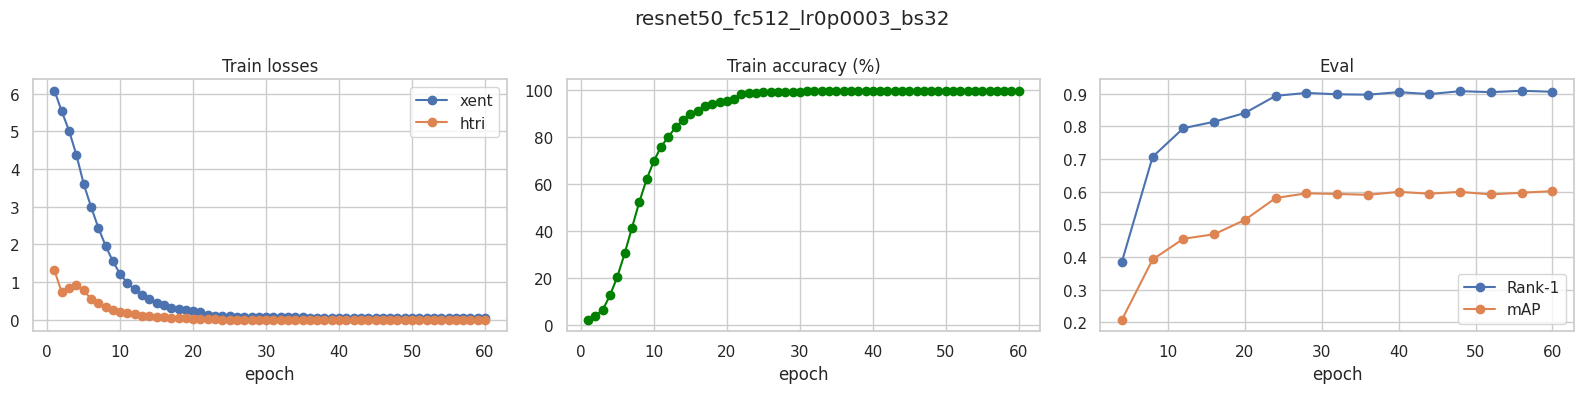


=== resnet50_fc512_lr0p0003_bs48  resnet50_fc512  lr=0.0003  bs=48  epochs=60  K=4 ===
/usr/local/lib/python3.12/dist-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(
2026-04-27 09:36:21.058789: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 09:36:21.078343: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777282581.101277   23324 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777282581.108783   2

### resnet50_fc512_lr0p0003_bs48  —  best Rank-1: 88.14% · best mAP: 57.56% · 4768s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,133.1709,6.2401,1.0165,1.1034,NaN,NaN,NaN,NaN,NaN
1,2,64.0646,6.1313,0.4418,1.4803,NaN,NaN,NaN,NaN,NaN
2,3,63.8533,6.0829,0.5179,1.8799,NaN,NaN,NaN,NaN,NaN
3,4,63.0331,5.8269,0.6590,2.7586,0.1830,0.3278,0.4327,0.5560,0.1034
4,5,64.4176,5.3870,0.6585,5.0920,NaN,NaN,NaN,NaN,NaN
5,6,64.2448,5.0310,0.7882,7.2299,NaN,NaN,NaN,NaN,NaN
6,7,64.3748,4.4712,0.8700,12.2228,NaN,NaN,NaN,NaN,NaN
7,8,64.2091,3.7719,0.8113,19.5443,0.4994,0.6949,0.7878,0.8600,0.2685
8,9,64.0010,3.1180,0.6264,30.2619,NaN,NaN,NaN,NaN,NaN
9,10,63.6606,2.5499,0.5205,41.2275,NaN,NaN,NaN,NaN,NaN


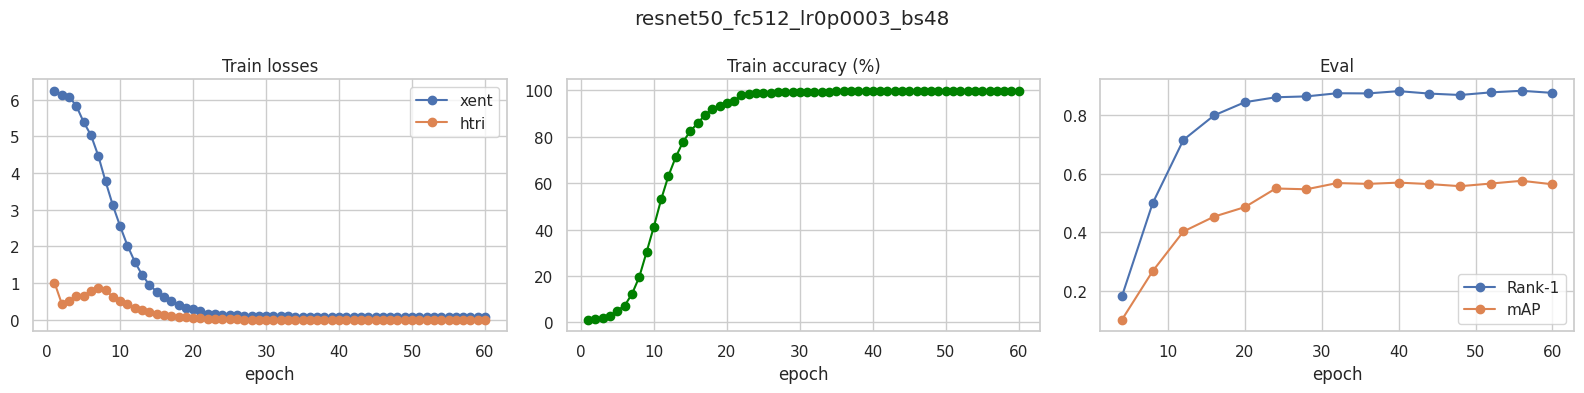


=== resnet50_fc512_lr0p0003_bs96  resnet50_fc512  lr=0.0003  bs=96  epochs=60  K=4 ===
/usr/local/lib/python3.12/dist-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(
2026-04-27 10:56:11.423979: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 10:56:11.443236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777287371.465569   43391 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777287371.473057   4

### resnet50_fc512_lr0p0003_bs96  —  best Rank-1: 92.61% · best mAP: 67.57% · 4486s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,129.2708,5.8720,0.9628,3.6122,NaN,NaN,NaN,NaN,NaN
1,2,60.0455,4.5632,0.8453,13.7605,NaN,NaN,NaN,NaN,NaN
2,3,59.1463,3.2192,0.6982,32.5256,NaN,NaN,NaN,NaN,NaN
3,4,59.0595,2.2379,0.4830,50.7056,0.7813,0.9035,0.9374,0.9571,0.4822
4,5,59.1666,1.5522,0.3384,65.0748,NaN,NaN,NaN,NaN,NaN
5,6,59.3995,1.1464,0.2612,73.8662,NaN,NaN,NaN,NaN,NaN
6,7,60.1514,0.8433,0.2155,81.3248,NaN,NaN,NaN,NaN,NaN
7,8,59.2632,0.6609,0.1711,85.5253,0.8570,0.9327,0.9583,0.9774,0.5685
8,9,59.7485,0.5163,0.1405,89.2602,NaN,NaN,NaN,NaN,NaN
9,10,60.2385,0.4256,0.1272,91.1848,NaN,NaN,NaN,NaN,NaN


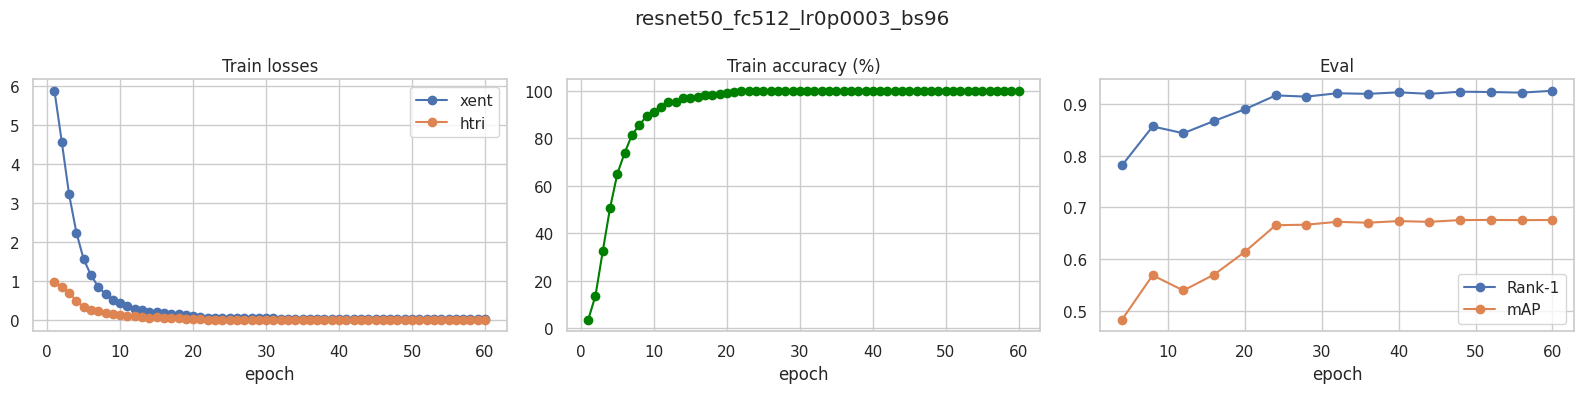


=== resnet50_fc512_lr0p0003_bs128  resnet50_fc512  lr=0.0003  bs=128  epochs=60  K=4 ===
/usr/local/lib/python3.12/dist-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(
2026-04-27 12:11:20.300608: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 12:11:20.319664: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777291880.341959   62257 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777291880.349333  

### resnet50_fc512_lr0p0003_bs128  —  best Rank-1: 92.61% · best mAP: 67.81% · 4405s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,127.3156,5.7914,1.0114,3.7822,NaN,NaN,NaN,NaN,NaN
1,2,57.7080,4.6145,0.7511,13.5201,NaN,NaN,NaN,NaN,NaN
2,3,57.1547,3.3175,0.7041,32.2926,NaN,NaN,NaN,NaN,NaN
3,4,56.6156,2.3039,0.5285,50.5265,0.7986,0.9017,0.9380,0.9642,0.4995
4,5,57.8901,1.5836,0.3646,65.1276,NaN,NaN,NaN,NaN,NaN
5,6,57.3510,1.1405,0.2681,74.7424,NaN,NaN,NaN,NaN,NaN
6,7,57.0541,0.8710,0.2220,80.6711,NaN,NaN,NaN,NaN,NaN
7,8,57.8625,0.6915,0.1983,84.8921,0.8540,0.9327,0.9559,0.9738,0.5567
8,9,57.5073,0.5247,0.1432,88.9561,NaN,NaN,NaN,NaN,NaN
9,10,58.4415,0.4261,0.1234,91.2793,NaN,NaN,NaN,NaN,NaN


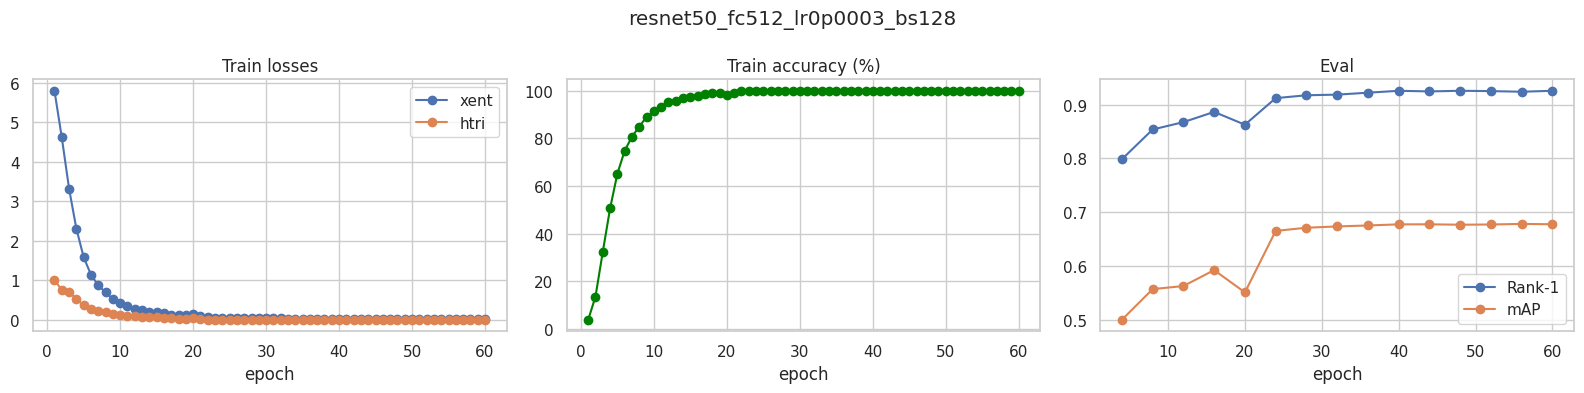

In [10]:
BEST_LR = "0.0003"  # <-- update after Q3.1

Q3_BS_VALUES = [32, 48, 96, 128]  # 4 values, all different from default bs=64

Q3_BS_SWEEP = {
    f"{Q3_CHOSEN_ARCH}_lr{_slug(BEST_LR)}_bs{bs}": {
        "arch": Q3_CHOSEN_ARCH, "lr": BEST_LR, "train_batch_size": bs
    }
    for bs in Q3_BS_VALUES
}

for name, cfg in Q3_BS_SWEEP.items():
    run_experiment(name, cfg, question="Q3")

### Summary

,experiment,best_rank1,best_mAP,final_rank1,final_mAP,avg_epoch_s,total_s
3,resnet50_fc512_lr0p0003_bs128,92.61%,67.81%,92.61%,67.75%,59.0,4405
2,resnet50_fc512_lr0p0003_bs96,92.61%,67.57%,92.61%,67.56%,61.0,4486
0,resnet50_fc512_lr0p0003_bs32,90.88%,60.17%,90.58%,60.17%,71.5,5125
1,resnet50_fc512_lr0p0003_bs48,88.14%,57.56%,87.43%,56.38%,65.3,4768


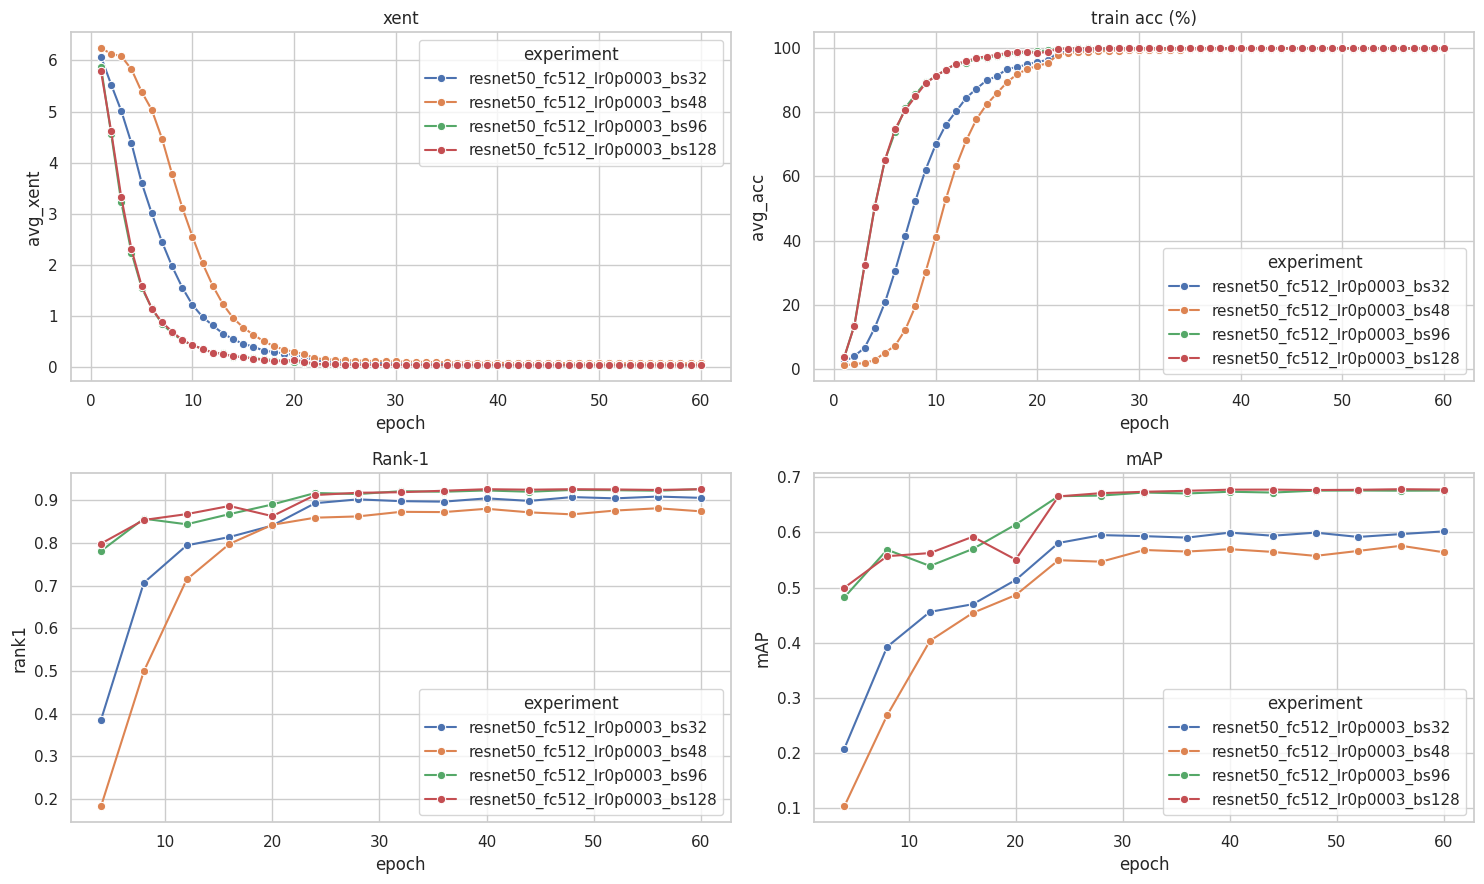

Wrote /content/reid/coursework/reports/comparison_2704_0809.html


,experiment,best_rank1,best_mAP,final_rank1,final_mAP,avg_epoch_s,total_s
3,resnet50_fc512_lr0p0003_bs128,0.926103,0.678128,0.926103,0.677470,59.010662,4405.474031
2,resnet50_fc512_lr0p0003_bs96,0.926103,0.675731,0.926103,0.675607,60.989892,4486.211988
0,resnet50_fc512_lr0p0003_bs32,0.908820,0.601686,0.905840,0.601686,71.495649,5125.327823
1,resnet50_fc512_lr0p0003_bs48,0.881406,0.575598,0.874255,0.563799,65.335262,4767.640814


In [12]:
compare_runs(
    #[f"logs/{RUNTIME}/Q1/{Q3_CHOSEN_ARCH}-veri"]  # baseline: default bs=64
    [f"logs/{RUNTIME}/Q3/{name}-veri" for name in Q3_BS_SWEEP],
    runtime=RUNTIME,
    html=True,
)

### Q3.3 — SGD at best LR + best BS

Set `BEST_BS` to the winner from Q3.2.

In [ ]:
BEST_BS = 64  # <-- update after Q3.2

Q3_OPTIM_SWEEP = {
    f"{Q3_CHOSEN_ARCH}_sgd_lr{_slug(BEST_LR)}_bs{BEST_BS}": {
        "arch": Q3_CHOSEN_ARCH,
        "lr": BEST_LR,
        "train_batch_size": BEST_BS,
        "optim": "sgd",
    },
}

for name, cfg in Q3_OPTIM_SWEEP.items():
    run_experiment(name, cfg, question="Q3")

In [ ]:
compare_runs(
    [
        f"logs/{RUNTIME}/Q1/{Q3_CHOSEN_ARCH}-veri",  # original AMSGrad baseline
        *[f"logs/{RUNTIME}/Q3/{name}-veri" for name in Q3_OPTIM_SWEEP],
    ],
    runtime=RUNTIME,
    html=True,
)


In [ ]:
NOTEBOOK_END_TIME = datetime.now()
NOTEBOOK_RUNTIME = (NOTEBOOK_END_TIME - NOTEBOOK_START_TIME).total_seconds()
print(f"Notebook Run time: {NOTEBOOK_RUNTIME:.2f} seconds")